In [8]:
import sys
import os
import pandas as pd

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
%load_ext autoreload
%autoreload 2
pjoin = os.path.join

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
from src.plotting.visutil import CSVPlotter
from src.utils.mathutil import ABCDUtil
from scripts.PrepABCD import prep_sign_rwgt, read_two_channels_df, get_mbb_train_test, train_mlp_rwgt, plot_rwgt_results, plot_avg_results

## Pre-clean datasets

In [31]:
Res1b_SS, Res2b_SS, Res1b_OS, Res2b_OS = read_two_channels_df('posttight')

In [32]:
Res1b_SS = prep_sign_rwgt(Res1b_SS)
Res2b_SS = prep_sign_rwgt(Res2b_SS)
Res1b_OS = prep_sign_rwgt(Res1b_OS)
Res2b_OS = prep_sign_rwgt(Res2b_OS)

In [25]:
total_vbf_SS = pd.concat([Res1b_SS, Res2b_SS], axis=0)
total_vbf_OS = pd.concat([Res1b_OS, Res2b_OS], axis=0)

In [29]:
# further split the data into training and testing based on tau_id
from scripts.PrepABCD import get_tauid_train_test

ss_1b, val_ss_1b, os_1b, val_os_1b = get_tauid_train_test(Res1b_SS, Res1b_OS)
ss_2b, val_ss_2b, os_2b, val_os_2b = get_tauid_train_test(Res2b_SS, Res2b_OS)

ABCD_Helper = ABCDUtil(val_os_1b, os_1b, val_ss_1b, ss_1b, 'weight')
print("Getting ABCD closure stats for 1b channel")
ABCD_Helper.get_all_stats()
ABCD_Helper = ABCDUtil(val_os_2b, os_2b, val_ss_2b, ss_2b, 'weight')
print("\n \n Getting ABCD closure stats for 2b channel")
ABCD_Helper.get_all_stats()

Getting ABCD closure stats for 1b channel
          Events (Raw)  Events (Weighted)  Stat. Uncertainty
Region                                                      
Region A         59914               3931          19.557778
Region B        122828               9402          31.856461
Region C         31507               2126          14.511846
Region D         91397               7202          28.144290
The closure stats for Events: 
                                    Raw      Weighted
Metric                                               
Predicted events in A    42342 ± 301.85  2775 ± 74.23
Prediction/Actual ratio           0.707         0.706
Pull significance                54.951        14.118
Deviation                        58.214        15.575
Percentage difference             29.3%         29.4%

 
 Getting ABCD closure stats for 2b channel
          Events (Raw)  Events (Weighted)  Stat. Uncertainty
Region                                                      
Region A       

In [30]:
vbf_ss, val_vbf_ss, vbf_os, val_vbf_os = get_tauid_train_test(total_vbf_SS, total_vbf_OS)
ABCD_Helper = ABCDUtil(val_vbf_os, vbf_os, val_vbf_ss, vbf_ss, 'weight')
print("\n \n Getting ABCD closure stats for VBF channel for Loose to Tight")
ABCD_Helper.get_all_stats()
# vbf_ss, val_vbf_ss, vbf_os, val_vbf_os = get_mbb_train_test(total_vbf_SS, total_vbf_OS)
# ABCD_Helper = ABCDUtil(val_vbf_os, vbf_os, val_vbf_ss, vbf_ss, 'weight')
# print("\n \n Getting ABCD closure stats for VBF channel for Mbb reweight")
# ABCD_Helper.get_all_stats()


 
 Getting ABCD closure stats for VBF channel for Loose to Tight
          Events (Raw)  Events (Weighted)  Stat. Uncertainty
Region                                                      
Region A          4940                315           5.523054
Region B         19738               1495          12.678745
Region C          3108                203           4.471091
Region D         15792               1232          11.600628
The closure stats for Events: 
                                  Raw     Weighted
Metric                                            
Predicted events in A    3884 ± 81.08  247 ± 19.74
Prediction/Actual ratio         0.786        0.782
Pull significance              11.242        2.902
Deviation                      13.025        3.488
Percentage difference           21.4%        21.8%


In [33]:
ss_1b, val_ss_1b, os_1b, val_os_1b = get_mbb_train_test(Res1b_SS, Res1b_OS)
ss_2b, val_ss_2b, os_2b, val_os_2b = get_mbb_train_test(Res2b_SS, Res2b_OS)
ABCD_Helper = ABCDUtil(val_os_1b, os_1b, val_ss_1b, ss_1b, 'weight')
print("Getting ABCD closure stats for 1b channel")
ABCD_Helper.get_all_stats()
ABCD_Helper = ABCDUtil(val_os_2b, os_2b, val_ss_2b, ss_2b, 'weight')
print("\n \n Getting ABCD closure stats for 2b channel")
ABCD_Helper.get_all_stats()

Getting ABCD closure stats for 1b channel
          Events (Raw)  Events (Weighted)  Stat. Uncertainty
Region                                                      
Region A         67858               4971          22.834145
Region B         47934               3456          19.019092
Region C         45568               3483          19.386229
Region D         32642               2436          16.128840
The closure stats for Events: 
                                    Raw       Weighted
Metric                                                
Predicted events in A    66915 ± 573.45  4941 ± 155.21
Prediction/Actual ratio           0.986          0.994
Pull significance                 2.569          0.307
Deviation                         1.644          0.197
Percentage difference              1.4%           0.6%

 
 Getting ABCD closure stats for 2b channel
          Events (Raw)  Events (Weighted)  Stat. Uncertainty
Region                                                      
Region A

In [32]:
mlp_rwgter = train_mlp_rwgt(ss_1b, os_1b)

Dropped  210  events with negative weights out of  32642  events.
Dropped  306  events with negative weights out of  47934  events.
Features: ['LDTau_pt', 'LDTau_eta', 'LDTau_phi', 'LDTau_mass', 'LDTau_dxy', 'LDTau_dz', 'SDTau_pt', 'SDTau_eta', 'SDTau_phi', 'SDTau_mass', 'SDTau_dxy', 'SDTau_dz', 'nTau_values', 'LDBjet_pt', 'LDBjet_eta', 'LDBjet_phi', 'LDBjet_mass', 'LDBjet_btag', 'LDBjet_pnetbtag', 'LDBjet_pnettau', 'LDBjet_nconstituents', 'SDBjet_pt', 'SDBjet_eta', 'SDBjet_phi', 'SDBjet_mass', 'SDBjet_btag', 'SDBjet_pnetbtag', 'SDBjet_pnettau', 'SDBjet_nconstituents', 'nJets_values', 'DiTau_pt', 'DiTau_eta', 'DiTau_phi', 'DiTau_mass', 'DiJet_pt', 'DiJet_eta', 'DiJet_phi', 'DiJet_mass', 'Tau_dR', 'Bjet_dR', 'RecoH_dR', 'HT', 'LDTau_px', 'LDTau_py', 'LDTau_pz', 'SDTau_px', 'SDTau_py', 'SDTau_pz', 'LDBjet_px', 'LDBjet_py', 'LDBjet_pz', 'SDBjet_px', 'SDBjet_py', 'SDBjet_pz', 'DiTau_px', 'DiTau_py', 'DiTau_pz', 'DiJet_px', 'DiJet_py', 'DiJet_pz']
Epoch 1/100, Train Loss: 0.0509, Val Loss: 

In [ ]:
drop_kwds = ['Gen', 'weight_values', 'Weight_values', 'OS', 'group', 'gen', 'dataset', 'label', 'id', 'year', 'Tau_charge', 'X_num']
src_df = pd.concat([ss_2b, val_ss_2b], axis=0)
tar_df = pd.concat([os_2b, val_os_2b], axis=0)
total_2b_rwgt = mlp_rwgter.reweight(src_df, tar_df.weight.sum(), drop_kwds, True, 'mlp_rewgt_2b_total') 
# total_1b_rwgt = mlp_rwgter.reweight(src_df, tar_df.weight.sum(), drop_kwds, True, 'mlp_rewgt_1b_total')

Dropped  704  events with negative weights out of  121066  events.


In [54]:
drop_kwds = ['Gen', 'weight_values', 'Weight_values', 'OS', 'group', 'gen', 'dataset', 'label', 'id', 'year', 'Tau_charge', 'X_num']
ss_1b, val_ss_1b, os_1b, val_os_1b = get_mbb_train_test(Res1b_SS, Res1b_OS, mbb_cut=0)
src_df = pd.concat([ss_1b, val_ss_1b], axis=0)
tar_df = pd.concat([os_1b, val_os_1b], axis=0)
total_1b_rwgt = mlp_rwgter.reweight(src_df, tar_df.weight.sum(), drop_kwds, True, 'mlp_rewgt_1b_total') 

Dropped  554  events with negative weights out of  122904  events.


In [ ]:
total_1b_rwgt = pd.read_csv('')

In [58]:
show_infer = lambda df: df.copy()[df['DiJet_mass'] < 160]

/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:178: RuntimeWarning: invalid value encountered in divide
  density_hist * (np.sqrt(hist)/hist),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:178: RuntimeWarning: invalid value encountered in divide
  density_hist * (np.sqrt(hist)/hist),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:178: RuntimeWarning: invalid value encountered in divide
  density_hist * (np.sqrt(hist)/hist),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:178: RuntimeWarning: invalid value encountered in divide
  density_hist * (np.sqrt(hist)/hist),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:178: RuntimeWarning: invalid value encountered in divide
  density_hist * (np.sqrt(hist)/hist),


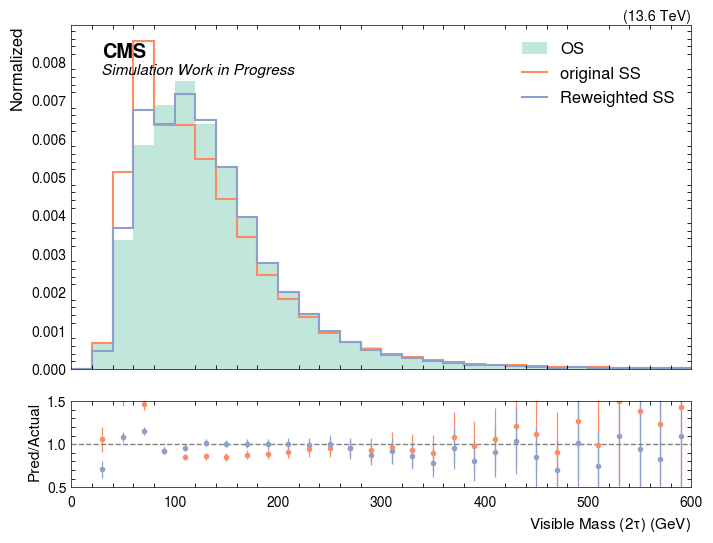

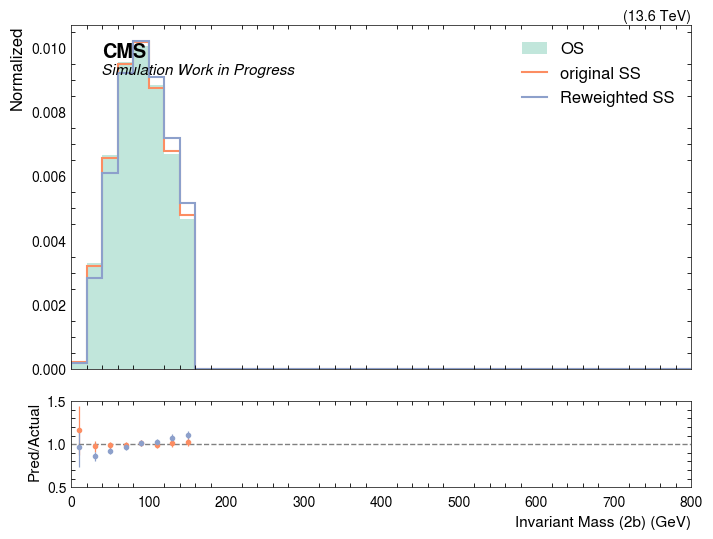

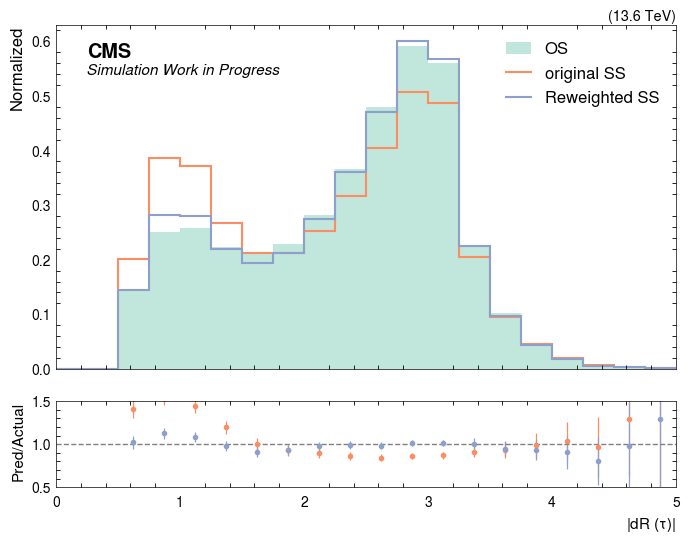

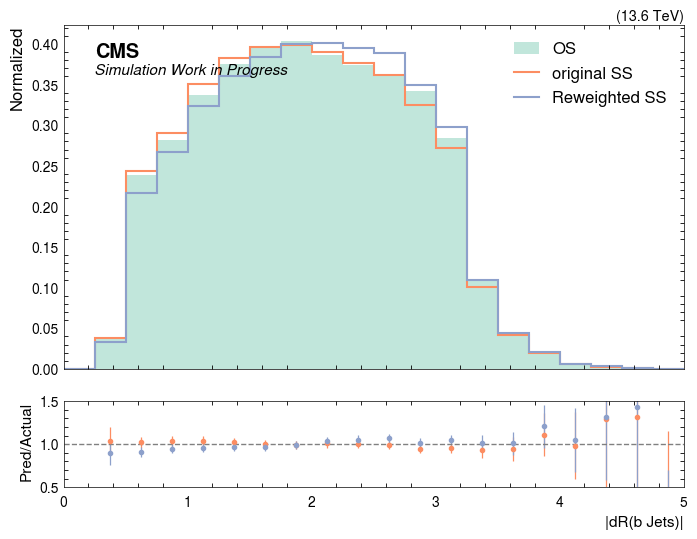

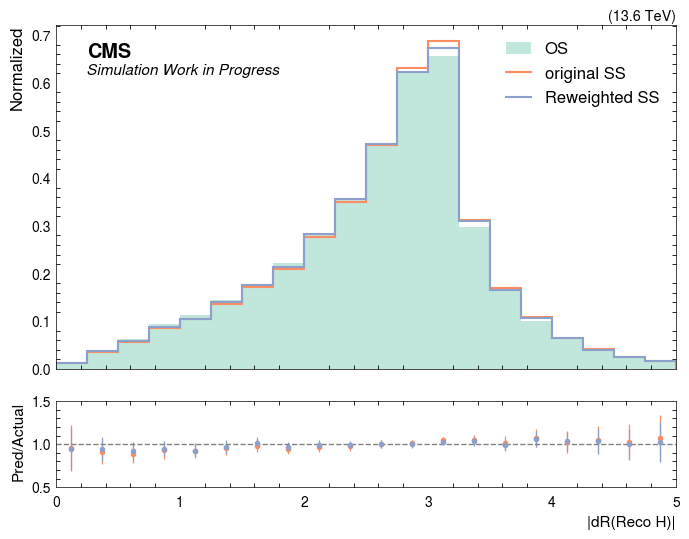

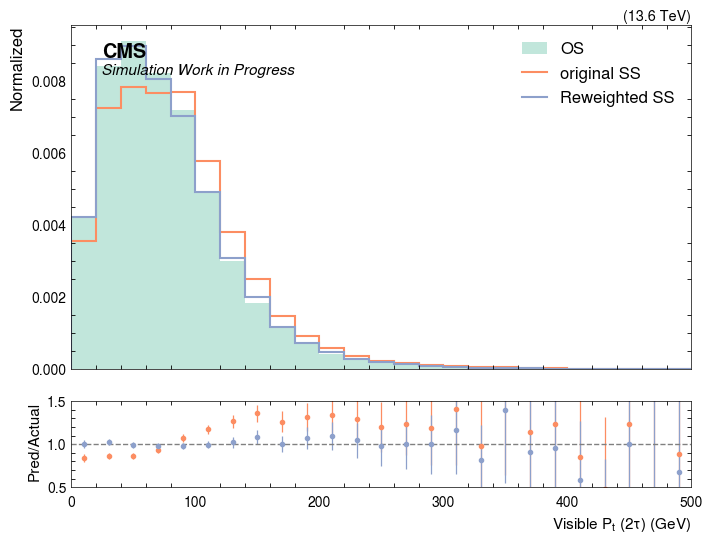

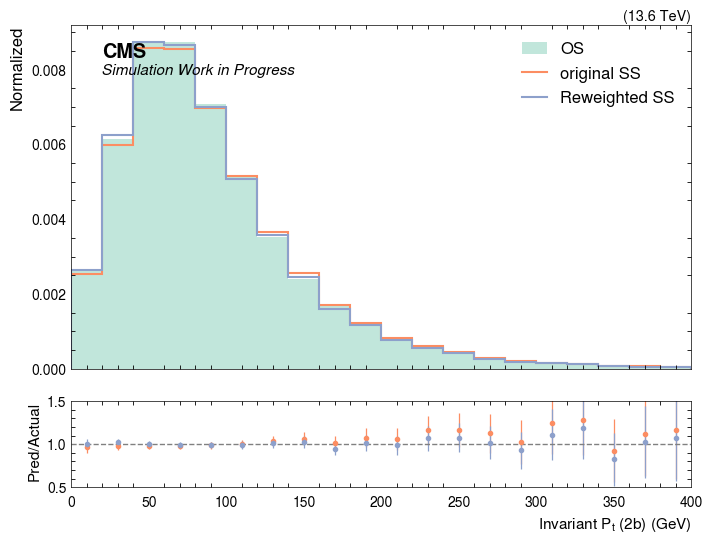

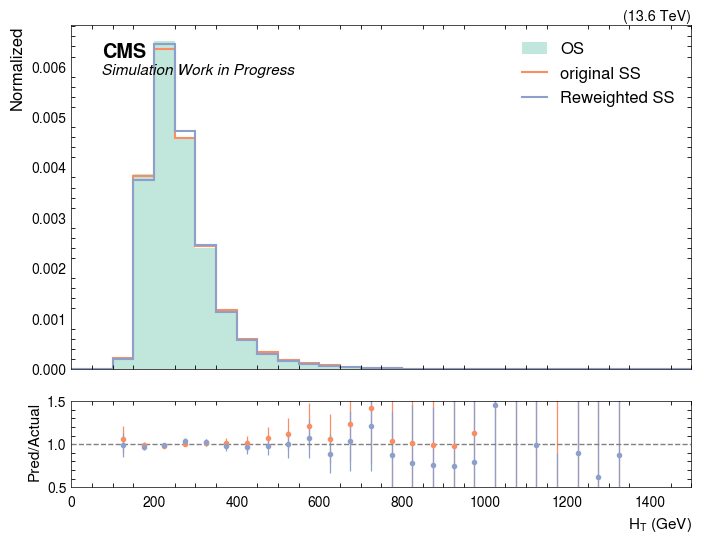

In [59]:
plot_dir_name = 'TTbar_1b'
out_dir = f'/Users/yuntongzhou/Desktop/Dihiggszztt/output/plots/{plot_dir_name}'
plot_rwgt_results(show_infer(src_df), show_infer(tar_df), show_infer(total_1b_rwgt), out_dir=out_dir)

/var/folders/w4/tl7q52611yg4x42kkpb7bm0m0000gn/T/ipykernel_3293/2275093166.py:2: DtypeWarning: Columns (78,79,80,81) have mixed types. Specify dtype option on import or set low_memory=False.
  total_2b_rwgt = pd.read_csv(f'{data_dir}/mlp_rewgt_2b_total.csv', index_col=0)
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:178: RuntimeWarning: invalid value encountered in divide
  density_hist * (np.sqrt(hist)/hist),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:178: RuntimeWarning: invalid value encountered in divide
  density_hist * (np.sqrt(hist)/hist),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:178: RuntimeWarning: invalid value encountered in divide
  density_hist * (np.sqrt(hist)/hist),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:178: RuntimeWarning: invalid value encountered in divide
  density_hist * (np.sqrt(hist)/hist),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtau

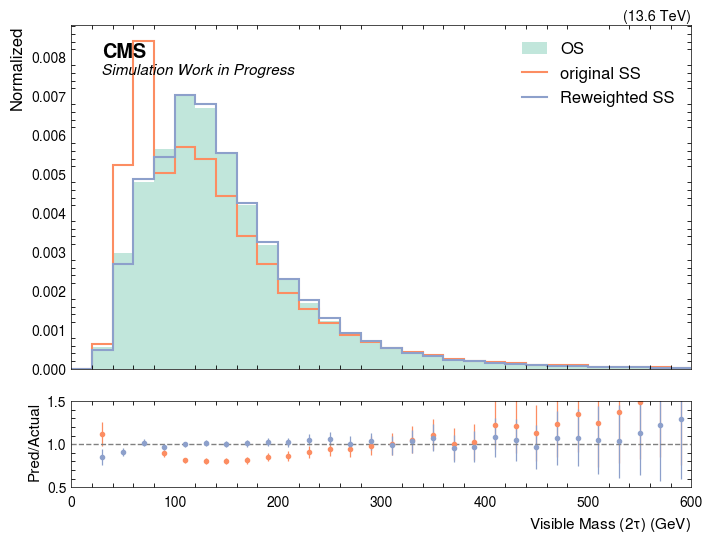

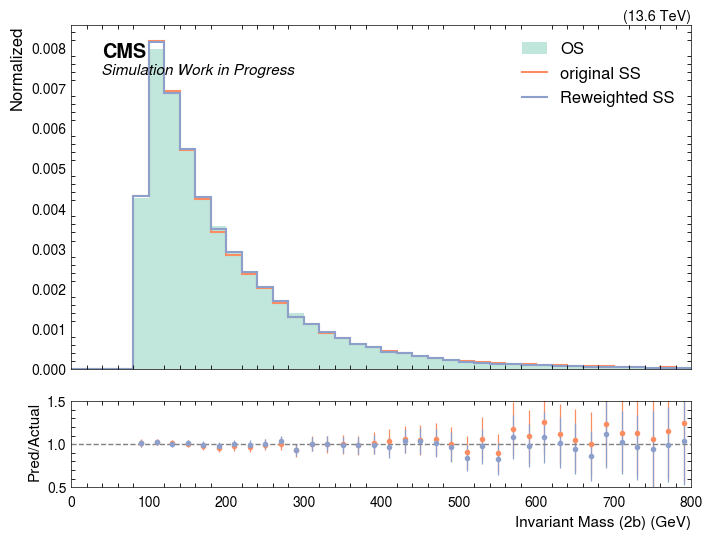

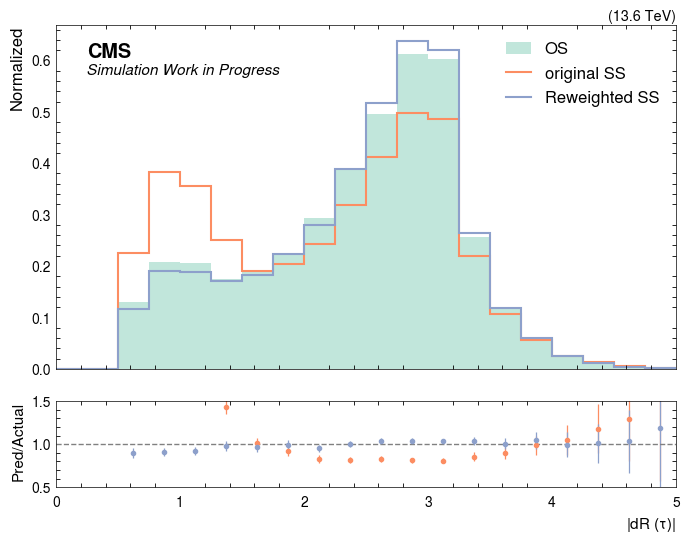

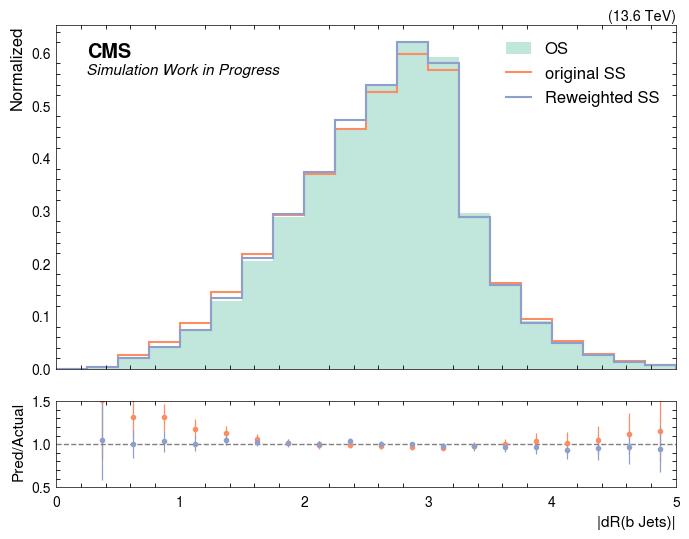

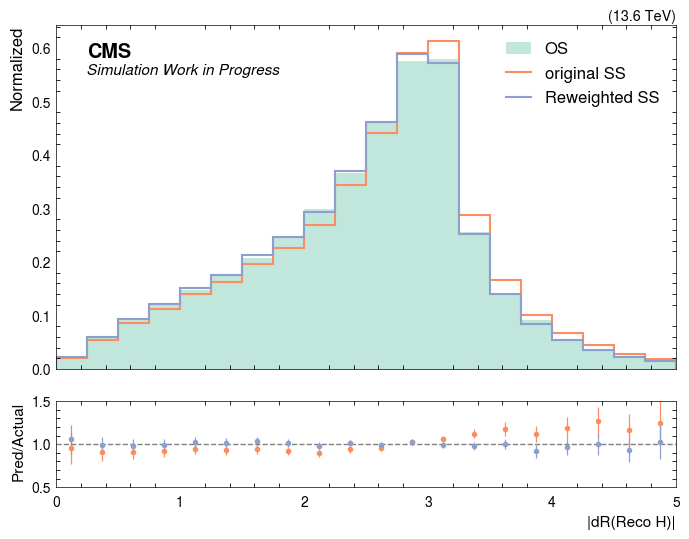

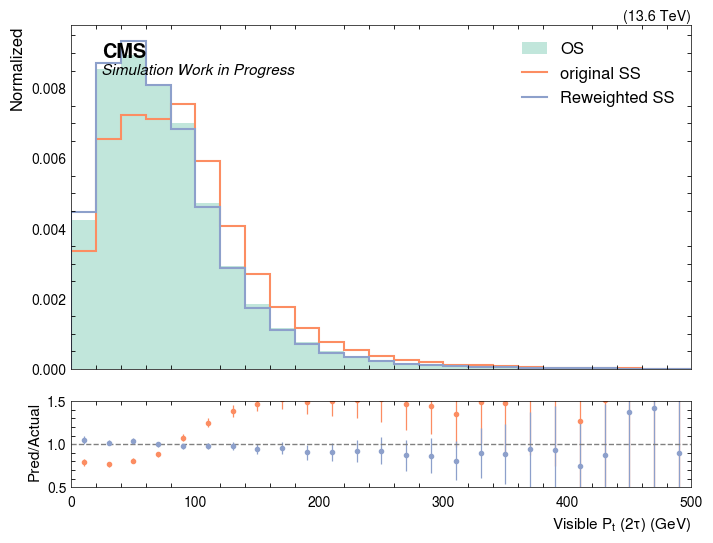

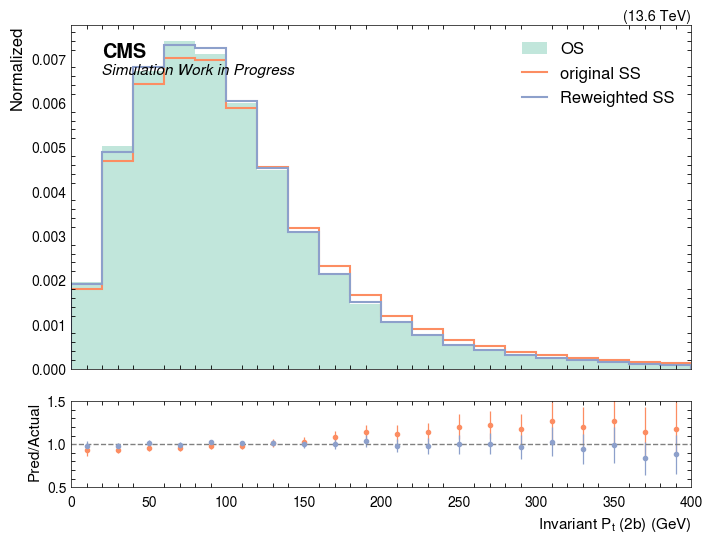

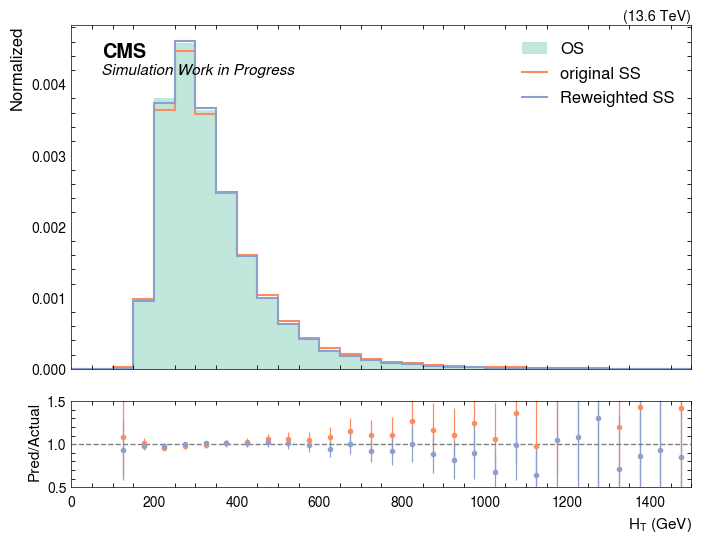

In [48]:
data_dir = "/Users/yuntongzhou/Desktop/Dihiggszztt/output/training/TopQuark"
total_2b_rwgt = pd.read_csv(f'{data_dir}/mlp_rewgt_2b_total.csv', index_col=0)

src_df = pd.concat([ss_2b, val_ss_2b], axis=0)
tar_df = pd.concat([os_2b, val_os_2b], axis=0)
plot_dir_name = 'TTbar_2b'
out_dir = f'/Users/yuntongzhou/Desktop/Dihiggszztt/output/plots/{plot_dir_name}'
plot_rwgt_results(src_df, tar_df, total_2b_rwgt, out_dir=out_dir)


/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:178: RuntimeWarning: invalid value encountered in divide
  density_hist * (np.sqrt(hist)/hist),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:178: RuntimeWarning: invalid value encountered in divide
  density_hist * (np.sqrt(hist)/hist),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:178: RuntimeWarning: invalid value encountered in divide
  density_hist * (np.sqrt(hist)/hist),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:178: RuntimeWarning: invalid value encountered in divide
  density_hist * (np.sqrt(hist)/hist),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:178: RuntimeWarning: invalid value encountered in divide
  density_hist * (np.sqrt(hist)/hist),


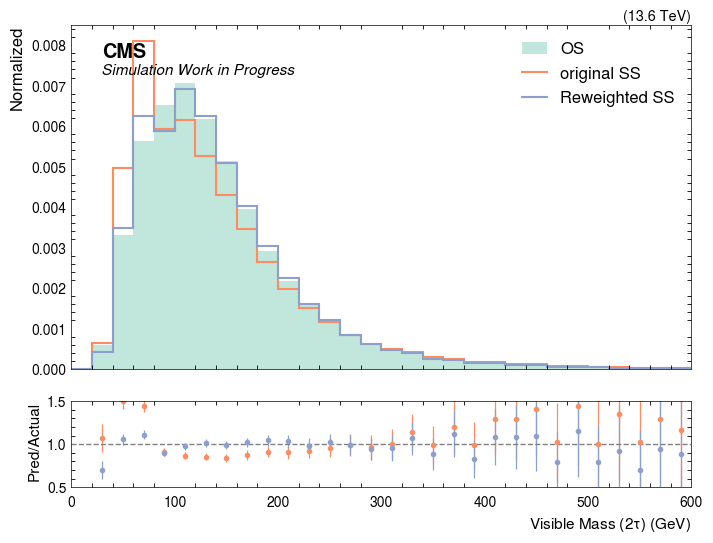

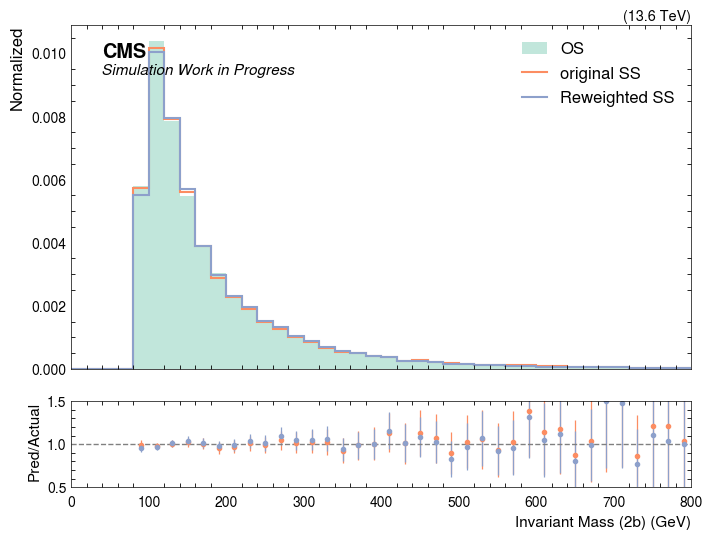

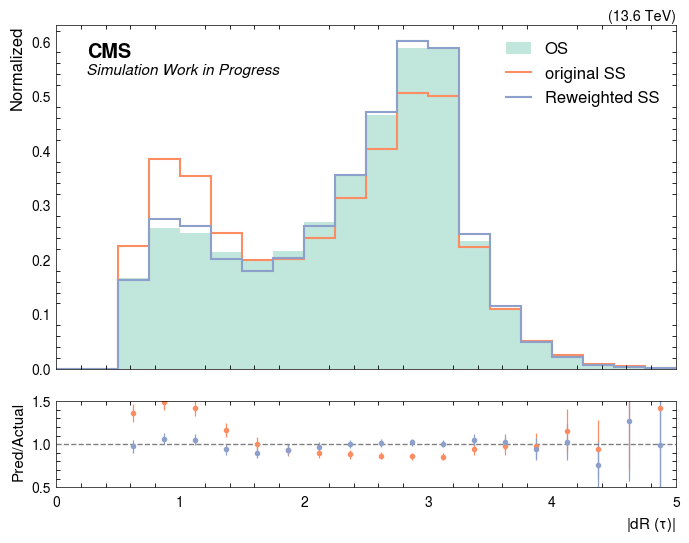

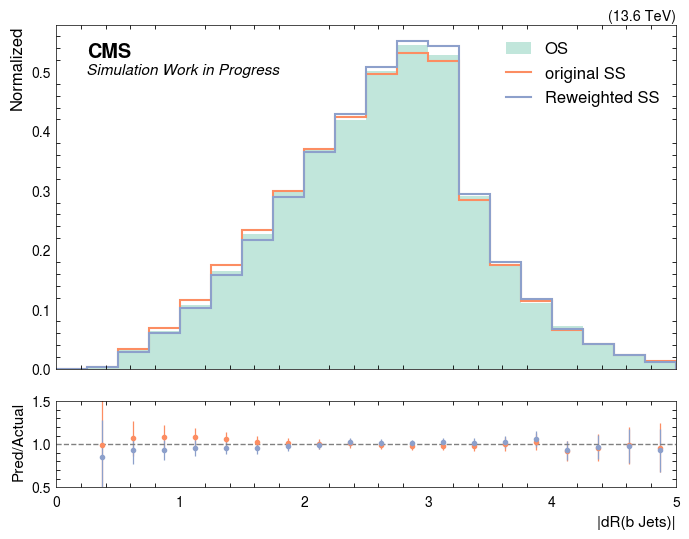

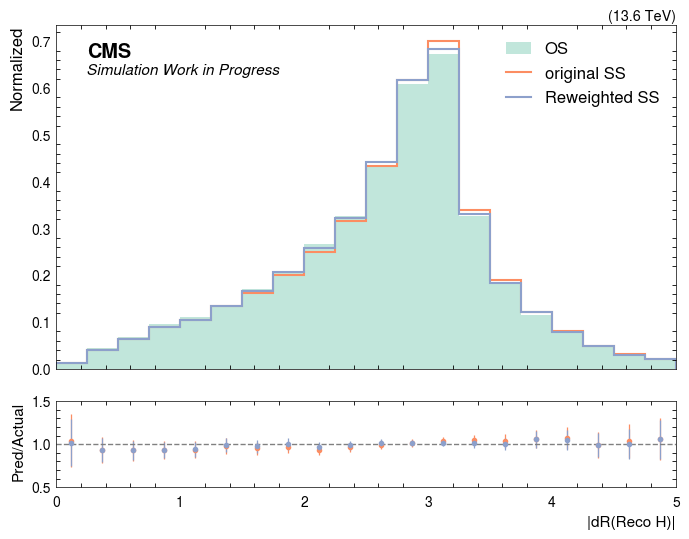

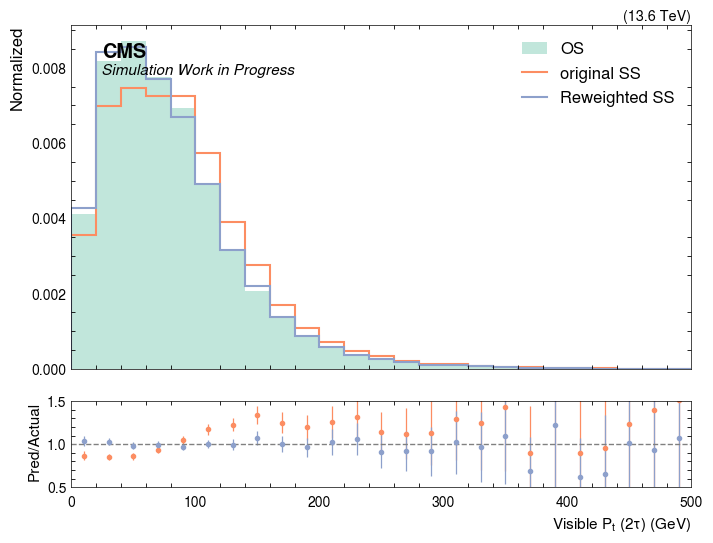

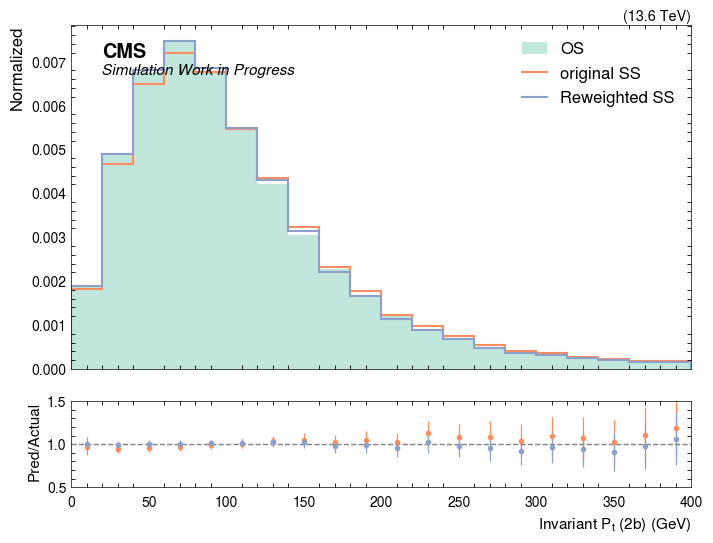

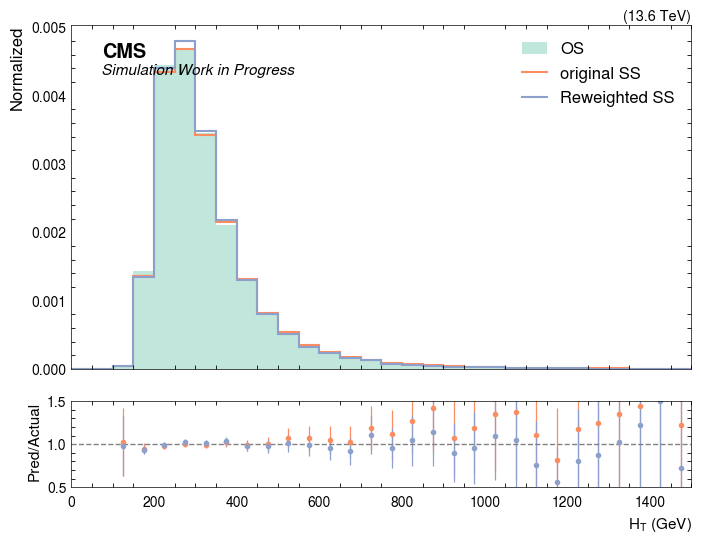